In [ ]:

from pydantic import BaseModel, Field
from typing import List, Optional

# ==========================================
# PHASE 1: Extraction & Classification Models
# ==========================================

class EducationalMetadata(BaseModel):
    """Stage 2: Educational Classification """
    subject: str = Field(..., description="The primary academic subject (e.g., Physics, History).")
    grade: str = Field(..., description="The target grade or education level (e.g., 10th Grade, Undergraduate).")
    difficulty: str = Field(..., description="Difficulty level: Beginner, Intermediate, or Advanced.")
    topic: str = Field(..., description="The specific topic being covered.")
    chapter: str = Field(..., description="The broader chapter this topic belongs to.")
    category: str = Field(..., description="Category of the document (e.g., STEM, Humanities).")
    language: str = Field(default="English", description="The language of the document.")

class ExtractedKnowledge(BaseModel):
    """Stage 3: Structured Educational Representation """
    learning_objectives: List[str] = Field(..., description="Clear, actionable objectives students should achieve.")
    prerequisites: List[str] = Field(..., description="What students must know before this lesson.")
    concepts: List[str] = Field(..., description="Core concepts discussed in the text.")
    definitions: dict[str, str] = Field(..., description="Key terms and their precise definitions.")
    formulae: Optional[List[str]] = Field(default_factory=list, description="Any mathematical or scientific formulas found.")
    misconceptions: List[str] = Field(..., description="Common student misconceptions related to this topic.")

# ==========================================
# MASTER TKP MODEL (The Final Output)
# ==========================================

class TeacherKnowledgePackage(BaseModel):
    """
    Stage 10: The final compiled package representing the 
    Master TeacherKnowledgePackage.json.
    """
    metadata: EducationalMetadata
    knowledge_base: ExtractedKnowledge
    # We will define PeriodPlan, Activities, and Assessments as we build Phase 2!
    periods: List[dict] = Field(default_factory=list, description="Placeholder for Stage 4 Teaching Planner.")

In [23]:
import logging
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END, START
from langchain_openai import ChatOpenAI
from app.models.schemas import EducationalMetadata, ExtractedKnowledge, TeacherKnowledgePackage

class PipelineState(TypedDict):
    text: str
    educational_classification : EducationalMetadata
    knoledge_extraction : ExtractedKnowledge
    current_stage : str
    
def educational_classification_node(state: PipelineState) -> dict:
    llm = ChatOpenAI(model='sd')
    structured_llm = llm.with_structured_output(EducationalMetadata)
    res = structured_llm.invoke(state['text'])
    return {
        "educational_classification" : res,
        "current_stage" : "stage 3"
    }

def build_tkp_pipeline() -> dict:
    workflow = StateGraph(PipelineState)
    workflow.add_node("classify", educational_classification_node)
    
    # edges
    workflow.add_edge(START, "classify")
    workflow.add_edge("classify", END)
    
    return workflow.compile()


In [17]:
wkflow = build_tkp_pipeline()

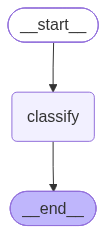

In [18]:
wkflow

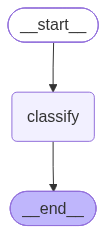

In [24]:
flow = build_tkp_pipeline()
flow

In [1]:
from sqlalchemy import text
from models.database import engine, Base
from core.logger import app_logger

def init_database():
    app_logger.info("Connecting to database to sync schemas...")
    
    with engine.connect() as conn:
        # 1. CRITICAL: Enable the pgvector extension FIRST
        app_logger.info("Enabling pgvector extension...")
        conn.execute(text("CREATE EXTENSION IF NOT EXISTS vector;"))
        conn.commit()
        
    # 2. Create the tables (this translates your Python classes into SQL CREATE TABLE commands)
    app_logger.info("Creating tables...")
    Base.metadata.create_all(bind=engine)
    
    app_logger.info("Database sync complete! 'document_chunks' table is ready.")

# Run the initialization
init_database()

2026-08-02 17:09:38,649 | INFO     | TeacherAI | Connecting to database to sync schemas...
2026-08-02 17:09:39,457 | INFO     | TeacherAI | Enabling pgvector extension...


NotSupportedError: (psycopg2.errors.FeatureNotSupported) extension "vector" is not available
DETAIL:  Could not open extension control file "C:/Program Files/PostgreSQL/16/share/extension/vector.control": No such file or directory.
HINT:  The extension must first be installed on the system where PostgreSQL is running.

[SQL: CREATE EXTENSION IF NOT EXISTS vector;]
(Background on this error at: https://sqlalche.me/e/20/tw8g)